In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [10]:
# =============================================================================
# STEP 1: UNDERSTANDING THE DATASET
# =============================================================================

import pandas as pd

# Load the dataset
df = pd.read_csv("../../../data/raw/diabetes.csv")   # Update path if needed


print("=" * 70)
print("DATASET SHAPE")
print("=" * 70)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")


print("\n" + "=" * 70)
print("FEATURE NAMES")
print("=" * 70)
print(df.columns.tolist())


print("\n" + "=" * 70)
print("FIRST FIVE RECORDS")
print("=" * 70)
display(df.head())


print("\n" + "=" * 70)
print("LAST FIVE RECORDS")
print("=" * 70)
display(df.tail())


print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)
df.info()


print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)
display(df.dtypes.to_frame(name="Data Type"))


print("\n" + "=" * 70)
print("MISSING VALUES OVERVIEW")
print("=" * 70)

missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum()/len(df))*100
})

display(missing_summary)


print("\n" + "=" * 70)
print("DUPLICATE RECORDS")
print("=" * 70)
print(f"Total Duplicate Rows : {df.duplicated().sum()}")


print("\n" + "=" * 70)
print("SUMMARY STATISTICS - NUMERICAL FEATURES")
print("=" * 70)
display(df.describe().T)


print("\n" + "=" * 70)
print("SUMMARY STATISTICS - CATEGORICAL FEATURES")
print("=" * 70)

categorical_cols = df.select_dtypes(include="object").columns

if len(categorical_cols) > 0:
    display(df.describe(include="object").T)
else:
    print("No categorical features found")


print("\n" + "=" * 70)
print("MEMORY USAGE")
print("=" * 70)

memory_usage = df.memory_usage(deep=True).sum() / (1024**2)

print(f"Memory Usage : {memory_usage:.2f} MB")

DATASET SHAPE
Rows    : 253680
Columns : 22

FEATURE NAMES
['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

FIRST FIVE RECORDS


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0



LAST FIVE RECORDS


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0
253679,1.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,9.0,6.0,2.0



DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 no

...


MISSING VALUES OVERVIEW


,Missing Count,Missing Percentage
Diabetes_binary,0,0.0
HighBP,0,0.0
HighChol,0,0.0
CholCheck,0,0.0
BMI,0,0.0
Smoker,0,0.0
Stroke,0,0.0
HeartDiseaseorAttack,0,0.0
PhysActivity,0,0.0
Fruits,0,0.0



DUPLICATE RECORDS
Total Duplicate Rows : 24206

SUMMARY STATISTICS - NUMERICAL FEATURES


,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0



SUMMARY STATISTICS - CATEGORICAL FEATURES
No categorical features found

MEMORY USAGE
Memory Usage : 42.58 MB


In [11]:
# =============================================================================
# STEP 2: MISSING VALUE ANALYSIS
# =============================================================================


print("=" * 70)
print("MISSING VALUE COUNT")
print("=" * 70)

missing_count = df.isnull().sum()

display(
    missing_count.to_frame(name="Missing Values")
)


print("\n" + "=" * 70)
print("MISSING VALUE PERCENTAGE")
print("=" * 70)

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage (%)": missing_percentage.round(2)
})

display(missing_summary)


print("\n" + "=" * 70)
print("FEATURES WITH MISSING VALUES")
print("=" * 70)

missing_features = missing_summary[
    missing_summary["Missing Count"] > 0
]

if len(missing_features) > 0:
    display(missing_features)
else:
    print("No missing values found in the dataset")


print("\n" + "=" * 70)
print("MISSING VALUE VISUALIZATION")
print("=" * 70)

import matplotlib.pyplot as plt
import seaborn as sns

missing_plot = missing_summary[
    missing_summary["Missing Count"] > 0
]

if len(missing_plot) > 0:
    plt.figure(figsize=(10,5))

    sns.barplot(
        x=missing_plot.index,
        y=missing_plot["Missing Percentage (%)"]
    )

    plt.xticks(rotation=45)
    plt.ylabel("Missing Percentage (%)")
    plt.xlabel("Features")
    plt.title("Missing Value Percentage by Feature")
    plt.show()

else:
    print("No missing values to visualize")


print("\n" + "=" * 70)
print("TOTAL MISSING VALUES")
print("=" * 70)

total_missing = df.isnull().sum().sum()

print(f"Total Missing Values : {total_missing}")

MISSING VALUE COUNT


,Missing Values
Diabetes_binary,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0



MISSING VALUE PERCENTAGE


,Missing Count,Missing Percentage (%)
Diabetes_binary,0,0.0
HighBP,0,0.0
HighChol,0,0.0
CholCheck,0,0.0
BMI,0,0.0
Smoker,0,0.0
Stroke,0,0.0
HeartDiseaseorAttack,0,0.0
PhysActivity,0,0.0
Fruits,0,0.0



FEATURES WITH MISSING VALUES
No missing values found in the dataset

MISSING VALUE VISUALIZATION
No missing values to visualize

TOTAL MISSING VALUES
Total Missing Values : 0


In [12]:
# =============================================================================
# STEP 3: DUPLICATE ANALYSIS
# =============================================================================


print("=" * 70)
print("TOTAL DUPLICATE RECORDS")
print("=" * 70)

duplicate_count = df.duplicated().sum()

print(f"Duplicate Rows : {duplicate_count}")


print("\n" + "=" * 70)
print("DUPLICATE PERCENTAGE")
print("=" * 70)

duplicate_percentage = (duplicate_count / len(df)) * 100

print(f"Duplicate Percentage : {duplicate_percentage:.2f}%")


print("\n" + "=" * 70)
print("DUPLICATE RECORDS PREVIEW")
print("=" * 70)

if duplicate_count > 0:
    
    duplicate_rows = df[df.duplicated(keep=False)]
    
    display(duplicate_rows.head())
    
else:
    print("No duplicate records found")


print("\n" + "=" * 70)
print("DATASET SIZE BEFORE DUPLICATE REMOVAL")
print("=" * 70)

print(f"Rows Before Removal : {df.shape[0]}")


print("\n" + "=" * 70)
print("DUPLICATE REMOVAL")
print("=" * 70)

# Create a copy for preprocessing
df_clean = df.drop_duplicates()

print(f"Rows After Removal : {df_clean.shape[0]}")


print("\n" + "=" * 70)
print("ROWS REMOVED")
print("=" * 70)

rows_removed = df.shape[0] - df_clean.shape[0]

print(f"Total Rows Removed : {rows_removed}")

TOTAL DUPLICATE RECORDS
Duplicate Rows : 24206

DUPLICATE PERCENTAGE
Duplicate Percentage : 9.54%

DUPLICATE RECORDS PREVIEW


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
25,0.0,0.0,0.0,1.0,32.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,6.0,8.0
29,0.0,0.0,1.0,1.0,31.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
44,0.0,0.0,1.0,1.0,31.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0
52,1.0,1.0,1.0,1.0,27.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,0.0,30.0,1.0,0.0,10.0,4.0,5.0



DATASET SIZE BEFORE DUPLICATE REMOVAL
Rows Before Removal : 253680

DUPLICATE REMOVAL
Rows After Removal : 229474

ROWS REMOVED
Total Rows Removed : 24206



DUPLICATE RECORD VISUALIZATION


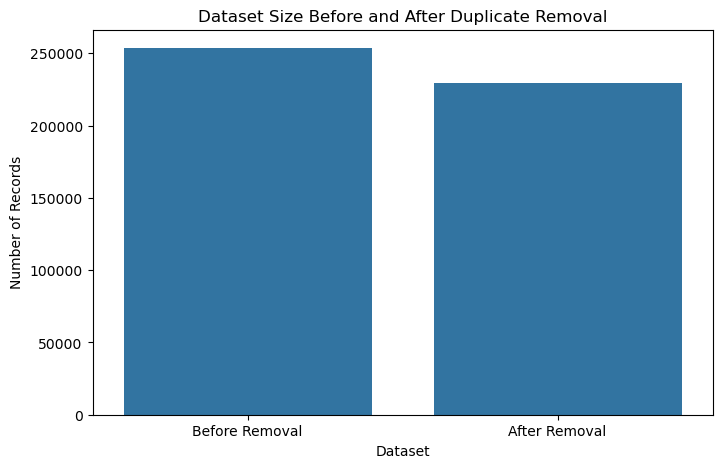


DUPLICATE VS UNIQUE RECORD DISTRIBUTION


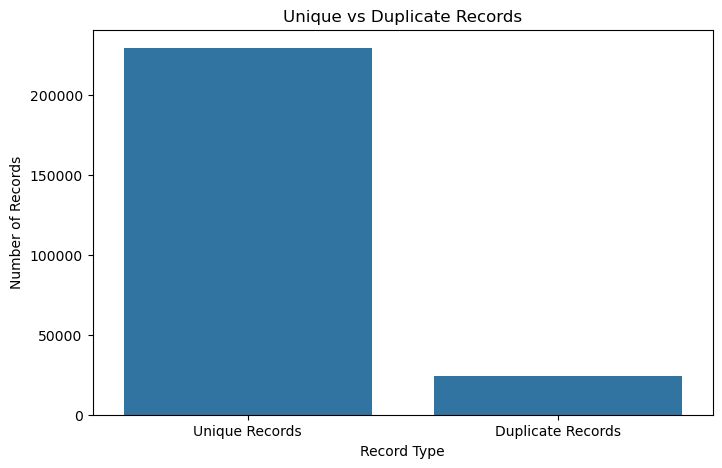

In [13]:
print("\n" + "=" * 70)
print("DUPLICATE RECORD VISUALIZATION")
print("=" * 70)

import matplotlib.pyplot as plt
import seaborn as sns


duplicate_comparison = pd.DataFrame({
    "Dataset": ["Before Removal", "After Removal"],
    "Number of Records": [
        df.shape[0],
        df_clean.shape[0]
    ]
})


plt.figure(figsize=(8,5))

sns.barplot(
    data=duplicate_comparison,
    x="Dataset",
    y="Number of Records"
)

plt.title("Dataset Size Before and After Duplicate Removal")
plt.ylabel("Number of Records")
plt.xlabel("Dataset")
plt.show()


print("\n" + "=" * 70)
print("DUPLICATE VS UNIQUE RECORD DISTRIBUTION")
print("=" * 70)


duplicate_distribution = pd.DataFrame({
    "Record Type": [
        "Unique Records",
        "Duplicate Records"
    ],
    "Count": [
        df_clean.shape[0],
        duplicate_count
    ]
})


plt.figure(figsize=(8,5))

sns.barplot(
    data=duplicate_distribution,
    x="Record Type",
    y="Count"
)

plt.title("Unique vs Duplicate Records")
plt.ylabel("Number of Records")
plt.xlabel("Record Type")
plt.show()

In [15]:
# =============================================================================
# STEP 4: UNIVARIATE ANALYSIS
# =============================================================================


# Use cleaned dataset after duplicate removal
df = df_clean.copy()


print("=" * 70)
print("NUMERICAL FEATURES")
print("=" * 70)


numerical_features = df.select_dtypes(
    include=['int64','float64']
).columns.tolist()

print(numerical_features)



print("\n" + "=" * 70)
print("NUMERICAL FEATURE STATISTICS")
print("=" * 70)

display(df[numerical_features].describe().T)



print("\n" + "=" * 70)
print("NUMERICAL FEATURE DISTRIBUTION")
print("=" * 70)



NUMERICAL FEATURES
['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

NUMERICAL FEATURE STATISTICS


,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,229474.0,0.152945,0.359936,0.0,0.0,0.0,0.0,1.0
HighBP,229474.0,0.454343,0.497912,0.0,0.0,0.0,1.0,1.0
HighChol,229474.0,0.441640,0.496584,0.0,0.0,0.0,1.0,1.0
CholCheck,229474.0,0.959481,0.197173,0.0,1.0,1.0,1.0,1.0
BMI,229474.0,28.687507,6.789204,12.0,24.0,27.0,32.0,98.0
Smoker,229474.0,0.465800,0.498830,0.0,0.0,0.0,1.0,1.0
Stroke,229474.0,0.044816,0.206899,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,229474.0,0.103336,0.304398,0.0,0.0,0.0,0.0,1.0
PhysActivity,229474.0,0.733042,0.442371,0.0,0.0,1.0,1.0,1.0
Fruits,229474.0,0.612675,0.487140,0.0,0.0,1.0,1.0,1.0



NUMERICAL FEATURE DISTRIBUTION


In [24]:
# =============================================================================
# CATEGORICAL FEATURE ANALYSIS (ENCODED FEATURES)
# =============================================================================


print("\n" + "=" * 70)
print("CATEGORICAL / BINARY FEATURES")
print("=" * 70)


categorical_features = [
    'HighBP',
    'HighChol',
    'CholCheck',
    'Smoker',
    'Stroke',
    'HeartDiseaseorAttack',
    'PhysActivity',
    'Fruits',
    'Veggies',
    'HvyAlcoholConsump',
    'AnyHealthcare',
    'NoDocbcCost',
    'DiffWalk',
    'Sex',
    'Diabetes_binary'
]


# Keep only columns present in dataset
categorical_features = [
    col for col in categorical_features 
    if col in df.columns
]


print(categorical_features)



print("\n" + "=" * 70)
print("CATEGORICAL FEATURE DISTRIBUTION")
print("=" * 70)


for feature in categorical_features:

    display(
        df[feature]
        .value_counts()
        .to_frame(name="Count")
    )



CATEGORICAL / BINARY FEATURES
['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex', 'Diabetes_binary']

CATEGORICAL FEATURE DISTRIBUTION


,Count
HighBP,
0.0,125214
1.0,104260


,Count
HighChol,
0.0,128129
1.0,101345


,Count
CholCheck,
1.0,220176
0.0,9298


,Count
Smoker,
0.0,122585
1.0,106889


...

,Count
AnyHealthcare,
1.0,217085
0.0,12389


,Count
NoDocbcCost,
0.0,208151
1.0,21323


,Count
DiffWalk,
0.0,186849
1.0,42625


,Count
Sex,
0.0,128715
1.0,100759


,Count
Diabetes_binary,
0.0,194377
1.0,35097


In [25]:
# =============================================================================
# STEP 5: OUTLIER ANALYSIS
# =============================================================================


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


print("=" * 70)
print("NUMERICAL FEATURES FOR OUTLIER ANALYSIS")
print("=" * 70)


# Select continuous numerical variables
numerical_features = [
    'BMI',
    'MentHlth',
    'PhysHlth'
]


# Keep only available columns
numerical_features = [
    col for col in numerical_features
    if col in df.columns
]


print(numerical_features)



print("\n" + "=" * 70)
print("OUTLIER DETECTION USING IQR METHOD")
print("=" * 70)


outlier_summary = []


for feature in numerical_features:
    
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    
    outliers = df[
        (df[feature] < lower_limit) |
        (df[feature] > upper_limit)
    ]
    
    
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df)) * 100
    
    
    outlier_summary.append({
        "Feature": feature,
        "Lower Bound": round(lower_limit,2),
        "Upper Bound": round(upper_limit,2),
        "Outlier Count": outlier_count,
        "Outlier Percentage (%)": round(outlier_percentage,2)
    })


outlier_df = pd.DataFrame(outlier_summary)

display(outlier_df)

NUMERICAL FEATURES FOR OUTLIER ANALYSIS
['BMI', 'MentHlth', 'PhysHlth']

OUTLIER DETECTION USING IQR METHOD


,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
0,BMI,12.0,44.0,5638,2.46
1,MentHlth,-3.0,5.0,36162,15.76
2,PhysHlth,-6.0,10.0,34346,14.97



BOXPLOT VISUALIZATION


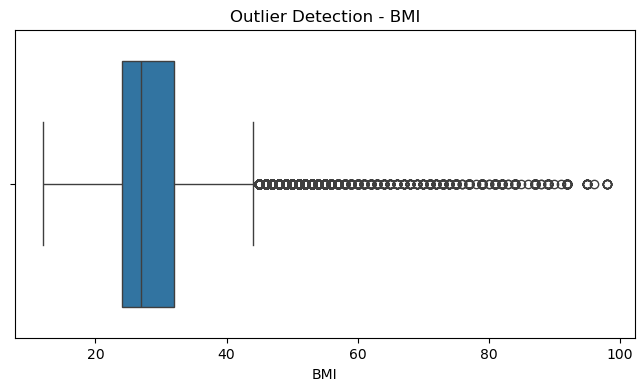

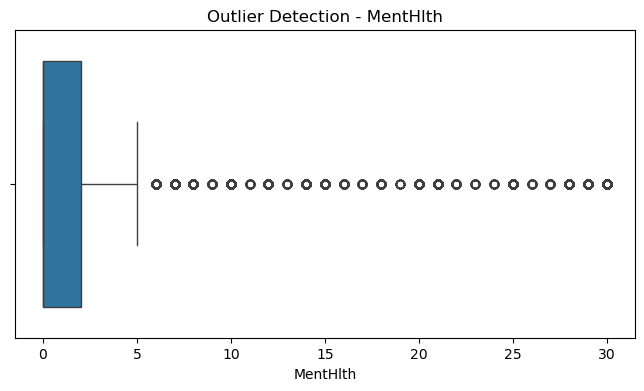

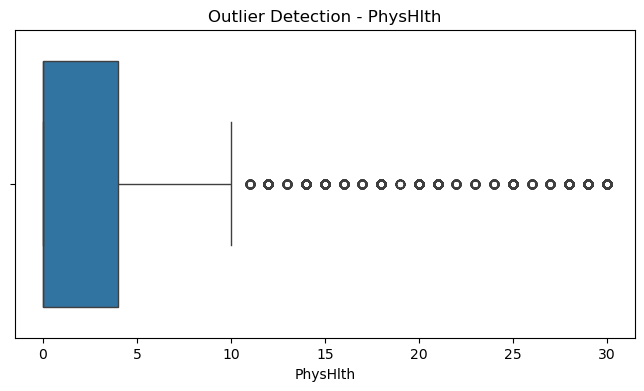

In [26]:
print("\n" + "=" * 70)
print("BOXPLOT VISUALIZATION")
print("=" * 70)


for feature in numerical_features:
    
    plt.figure(figsize=(8,4))
    
    sns.boxplot(
        x=df[feature]
    )
    
    plt.title(f"Outlier Detection - {feature}")
    plt.xlabel(feature)
    plt.show()


OUTLIER PERCENTAGE VISUALIZATION


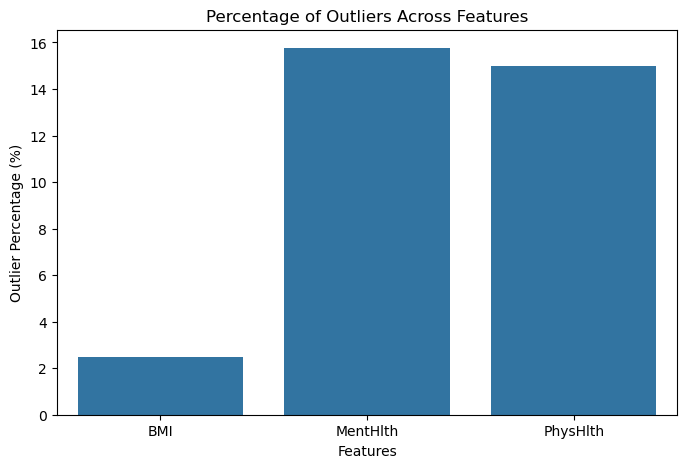

In [27]:
print("\n" + "=" * 70)
print("OUTLIER PERCENTAGE VISUALIZATION")
print("=" * 70)


plt.figure(figsize=(8,5))


sns.barplot(
    data=outlier_df,
    x="Feature",
    y="Outlier Percentage (%)"
)


plt.title("Percentage of Outliers Across Features")
plt.xlabel("Features")
plt.ylabel("Outlier Percentage (%)")
plt.show()

TARGET VARIABLE DISTRIBUTION
Diabetes_binary
0.0    194377
1.0     35097
Name: count, dtype: int64

CLASS DISTRIBUTION PERCENTAGE


,Class Count,Percentage (%)
Diabetes_binary,,
0.0,194377,84.71
1.0,35097,15.29



CLASS LABEL MAPPING
Class 0.0 : 194377 samples
Class 1.0 : 35097 samples

CLASS DISTRIBUTION VISUALIZATION


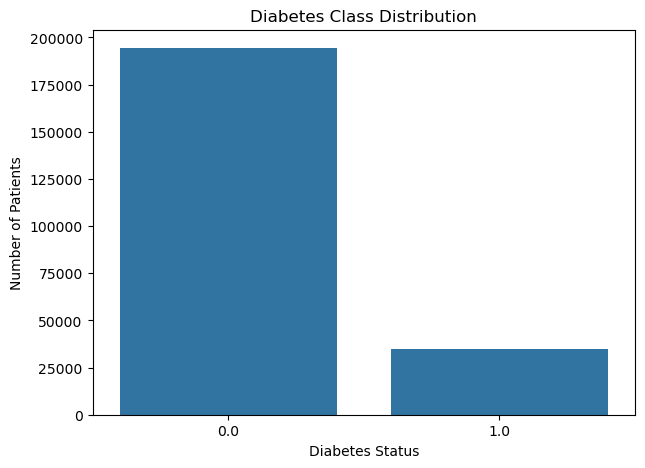


CLASS BALANCE RATIO
Minority/Majority Class Ratio : 0.181


In [30]:
# =============================================================================
# STEP 6: CLASS DISTRIBUTION ANALYSIS
# =============================================================================


print("=" * 70)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 70)


target_column = "Diabetes_binary"   # Update if your target name is different


print(df[target_column].value_counts())



print("\n" + "=" * 70)
print("CLASS DISTRIBUTION PERCENTAGE")
print("=" * 70)

class_distribution = pd.DataFrame({
    "Class Count": df[target_column].value_counts(),
    "Percentage (%)": (
        df[target_column]
        .value_counts(normalize=True) * 100
    ).round(2)
})


display(class_distribution)



print("\n" + "=" * 70)
print("CLASS LABEL MAPPING")
print("=" * 70)


for label, count in df[target_column].value_counts().items():
    
    print(f"Class {label} : {count} samples")



print("\n" + "=" * 70)
print("CLASS DISTRIBUTION VISUALIZATION")
print("=" * 70)


plt.figure(figsize=(7,5))


sns.countplot(
    data=df,
    x=target_column
)


plt.title("Diabetes Class Distribution")
plt.xlabel("Diabetes Status")
plt.ylabel("Number of Patients")
plt.show()



print("\n" + "=" * 70)
print("CLASS BALANCE RATIO")
print("=" * 70)


class_ratio = (
    df[target_column]
    .value_counts()
    .min()
    /
    df[target_column]
    .value_counts()
    .max()
)


print(f"Minority/Majority Class Ratio : {class_ratio:.3f}")

In [31]:
# =============================================================================
# STEP 7: CORRELATION ANALYSIS
# =============================================================================


import matplotlib.pyplot as plt
import seaborn as sns


print("=" * 70)
print("CORRELATION MATRIX")
print("=" * 70)


# Calculate correlation
correlation_matrix = df.corr()


display(correlation_matrix.round(2))

CORRELATION MATRIX


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
Diabetes_binary,1.00,0.25,0.19,0.07,0.21,0.05,0.10,0.17,-0.10,-0.02,...,0.03,0.02,0.28,0.05,0.16,0.21,0.03,0.18,-0.10,-0.14
HighBP,0.25,1.00,0.28,0.11,0.19,0.07,0.12,0.20,-0.10,-0.02,...,0.05,0.00,0.27,0.04,0.14,0.21,0.05,0.34,-0.11,-0.14
HighChol,0.19,0.28,1.00,0.09,0.09,0.07,0.09,0.18,-0.06,-0.03,...,0.05,0.00,0.19,0.05,0.11,0.14,0.02,0.26,-0.05,-0.06
CholCheck,0.07,0.11,0.09,1.00,0.04,-0.00,0.03,0.05,-0.00,0.02,...,0.12,-0.05,0.06,-0.00,0.04,0.05,-0.02,0.10,-0.01,0.00
BMI,0.21,0.19,0.09,0.04,1.00,-0.01,0.01,0.04,-0.13,-0.07,...,-0.01,0.05,0.21,0.07,0.10,0.18,0.03,-0.05,-0.07,-0.07
Smoker,0.05,0.07,0.07,-0.00,-0.01,1.00,0.05,0.11,-0.07,-0.06,...,-0.01,0.04,0.13,0.08,0.10,0.11,0.10,0.11,-0.14,-0.10
Stroke,0.10,0.12,0.09,0.03,0.01,0.05,1.00,0.20,-0.06,-0.00,...,0.01,0.03,0.17,0.06,0.14,0.17,0.00,0.13,-0.06,-0.12
HeartDiseaseorAttack,0.17,0.20,0.18,0.05,0.04,0.11,0.20,1.00,-0.07,-0.01,...,0.03,0.02,0.25,0.05,0.17,0.20,0.09,0.22,-0.08,-0.12
PhysActivity,-0.10,-0.10,-0.06,-0.00,-0.13,-0.07,-0.06,-0.07,1.00,0.13,...,0.02,-0.05,-0.24,-0.11,-0.20,-0.24,0.03,-0.09,0.17,0.17
Fruits,-0.02,-0.02,-0.03,0.02,-0.07,-0.06,-0.00,-0.01,0.13,1.00,...,0.02,-0.03,-0.07,-0.05,-0.02,-0.03,-0.09,0.07,0.08,0.05



CORRELATION HEATMAP


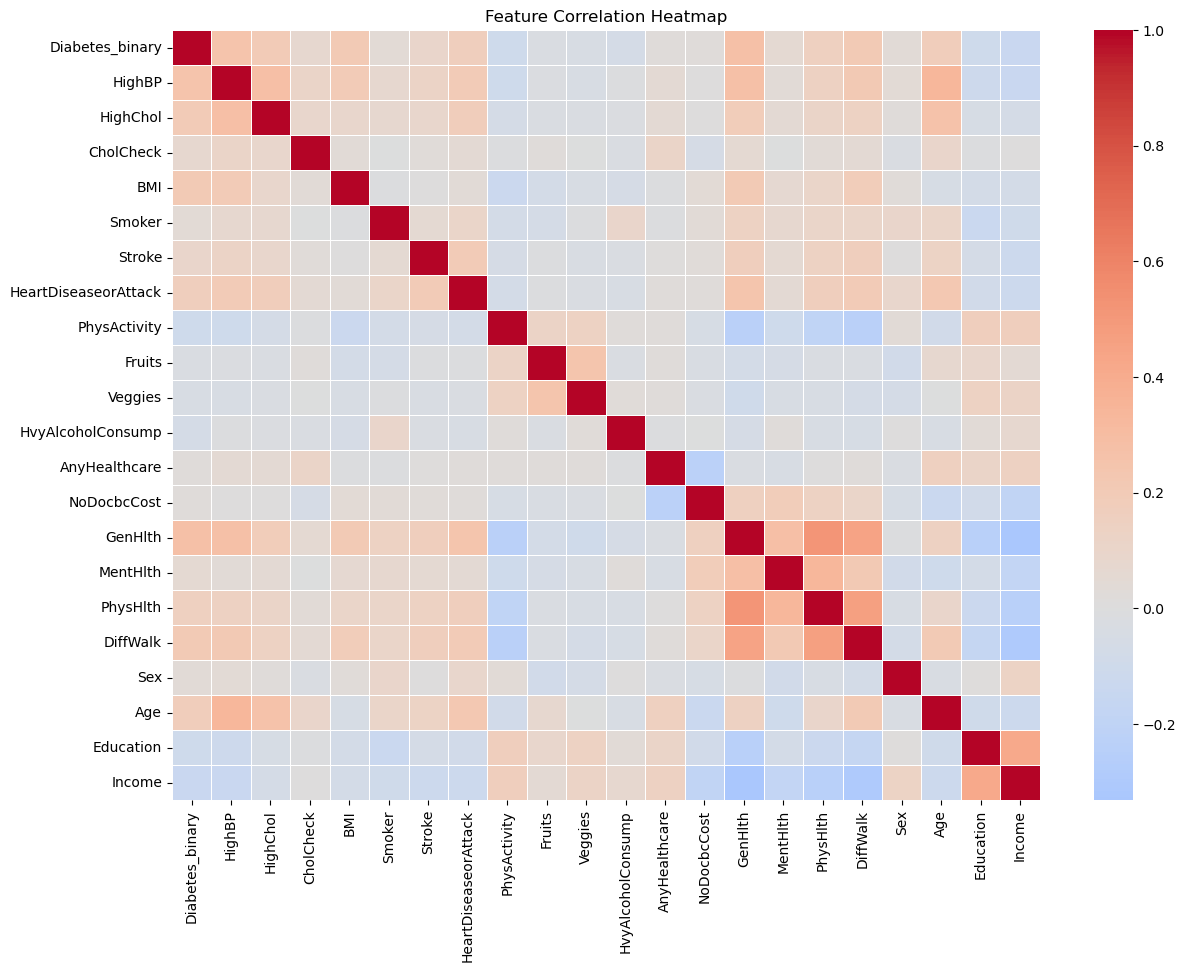

In [32]:
print("\n" + "=" * 70)
print("CORRELATION HEATMAP")
print("=" * 70)


plt.figure(figsize=(14,10))


sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)


plt.title("Feature Correlation Heatmap")
plt.show()

In [36]:
# =============================================================================
# STEP 8: RELATIONSHIP WITH TARGET VARIABLE
# =============================================================================


print("=" * 70)
print("TARGET VARIABLE RELATIONSHIP ANALYSIS")
print("=" * 70)


target_column = "Diabetes_binary"


# Separate numerical and categorical/binary features

numerical_features = [
    'BMI',
    'MentHlth',
    'PhysHlth'
]


numerical_features = [
    col for col in numerical_features
    if col in df.columns
]


categorical_features = [
    col for col in df.columns
    if col not in numerical_features + [target_column]
]


print("Numerical Features:")
print(numerical_features)


print("\nCategorical/Binary Features:")
print(categorical_features)

TARGET VARIABLE RELATIONSHIP ANALYSIS
Numerical Features:
['BMI', 'MentHlth', 'PhysHlth']

Categorical/Binary Features:
['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [37]:
print("\n" + "=" * 70)
print("NUMERICAL FEATURES BY DIABETES STATUS")
print("=" * 70)


for feature in numerical_features:
    
    print("\n")
    print("-"*60)
    print(feature)
    print("-"*60)
    
    display(
        df.groupby(target_column)[feature]
        .describe()
    )


NUMERICAL FEATURES BY DIABETES STATUS


------------------------------------------------------------
BMI
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,,,,,,,,
0.0,194377.0,28.095855,6.503252,12.0,24.0,27.0,31.0,98.0
1.0,35097.0,31.964242,7.380385,13.0,27.0,31.0,36.0,98.0




------------------------------------------------------------
MentHlth
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,,,,,,,,
0.0,194377.0,3.332277,7.455053,0.0,0.0,0.0,2.0,30.0
1.0,35097.0,4.493404,8.971501,0.0,0.0,0.0,3.0,30.0




------------------------------------------------------------
PhysHlth
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,,,,,,,,
0.0,194377.0,4.080442,8.438609,0.0,0.0,0.0,3.0,30.0
1.0,35097.0,8.008491,11.320659,0.0,0.0,1.0,15.0,30.0


NUMERICAL FEATURES VS DIABETES STATUS


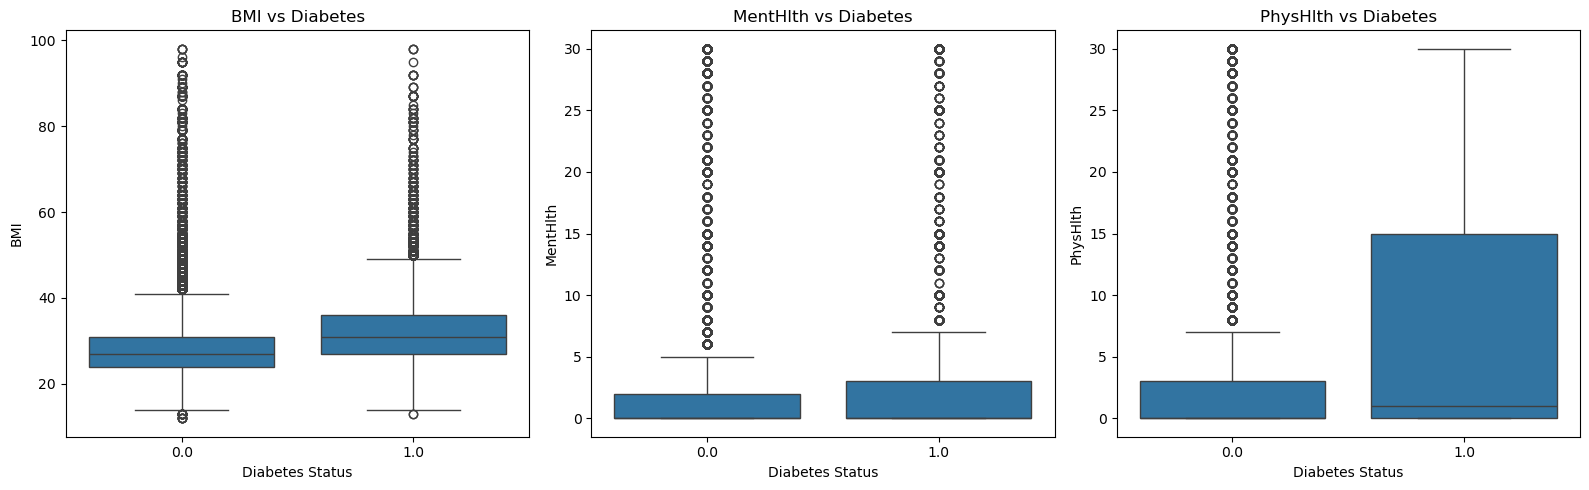

In [41]:
# =============================================================================
# NUMERICAL FEATURES VS TARGET (COMBINED VISUALIZATION)
# =============================================================================

print("=" * 70)
print("NUMERICAL FEATURES VS DIABETES STATUS")
print("=" * 70)


fig, axes = plt.subplots(
    nrows=1,
    ncols=len(numerical_features),
    figsize=(16,5)
)


for i, feature in enumerate(numerical_features):
    
    sns.boxplot(
        data=df,
        x=target_column,
        y=feature,
        ax=axes[i]
    )
    
    axes[i].set_title(
        f"{feature} vs Diabetes"
    )
    
    axes[i].set_xlabel("Diabetes Status")
    axes[i].set_ylabel(feature)


plt.tight_layout()
plt.show()

BINARY FEATURES VS DIABETES STATUS


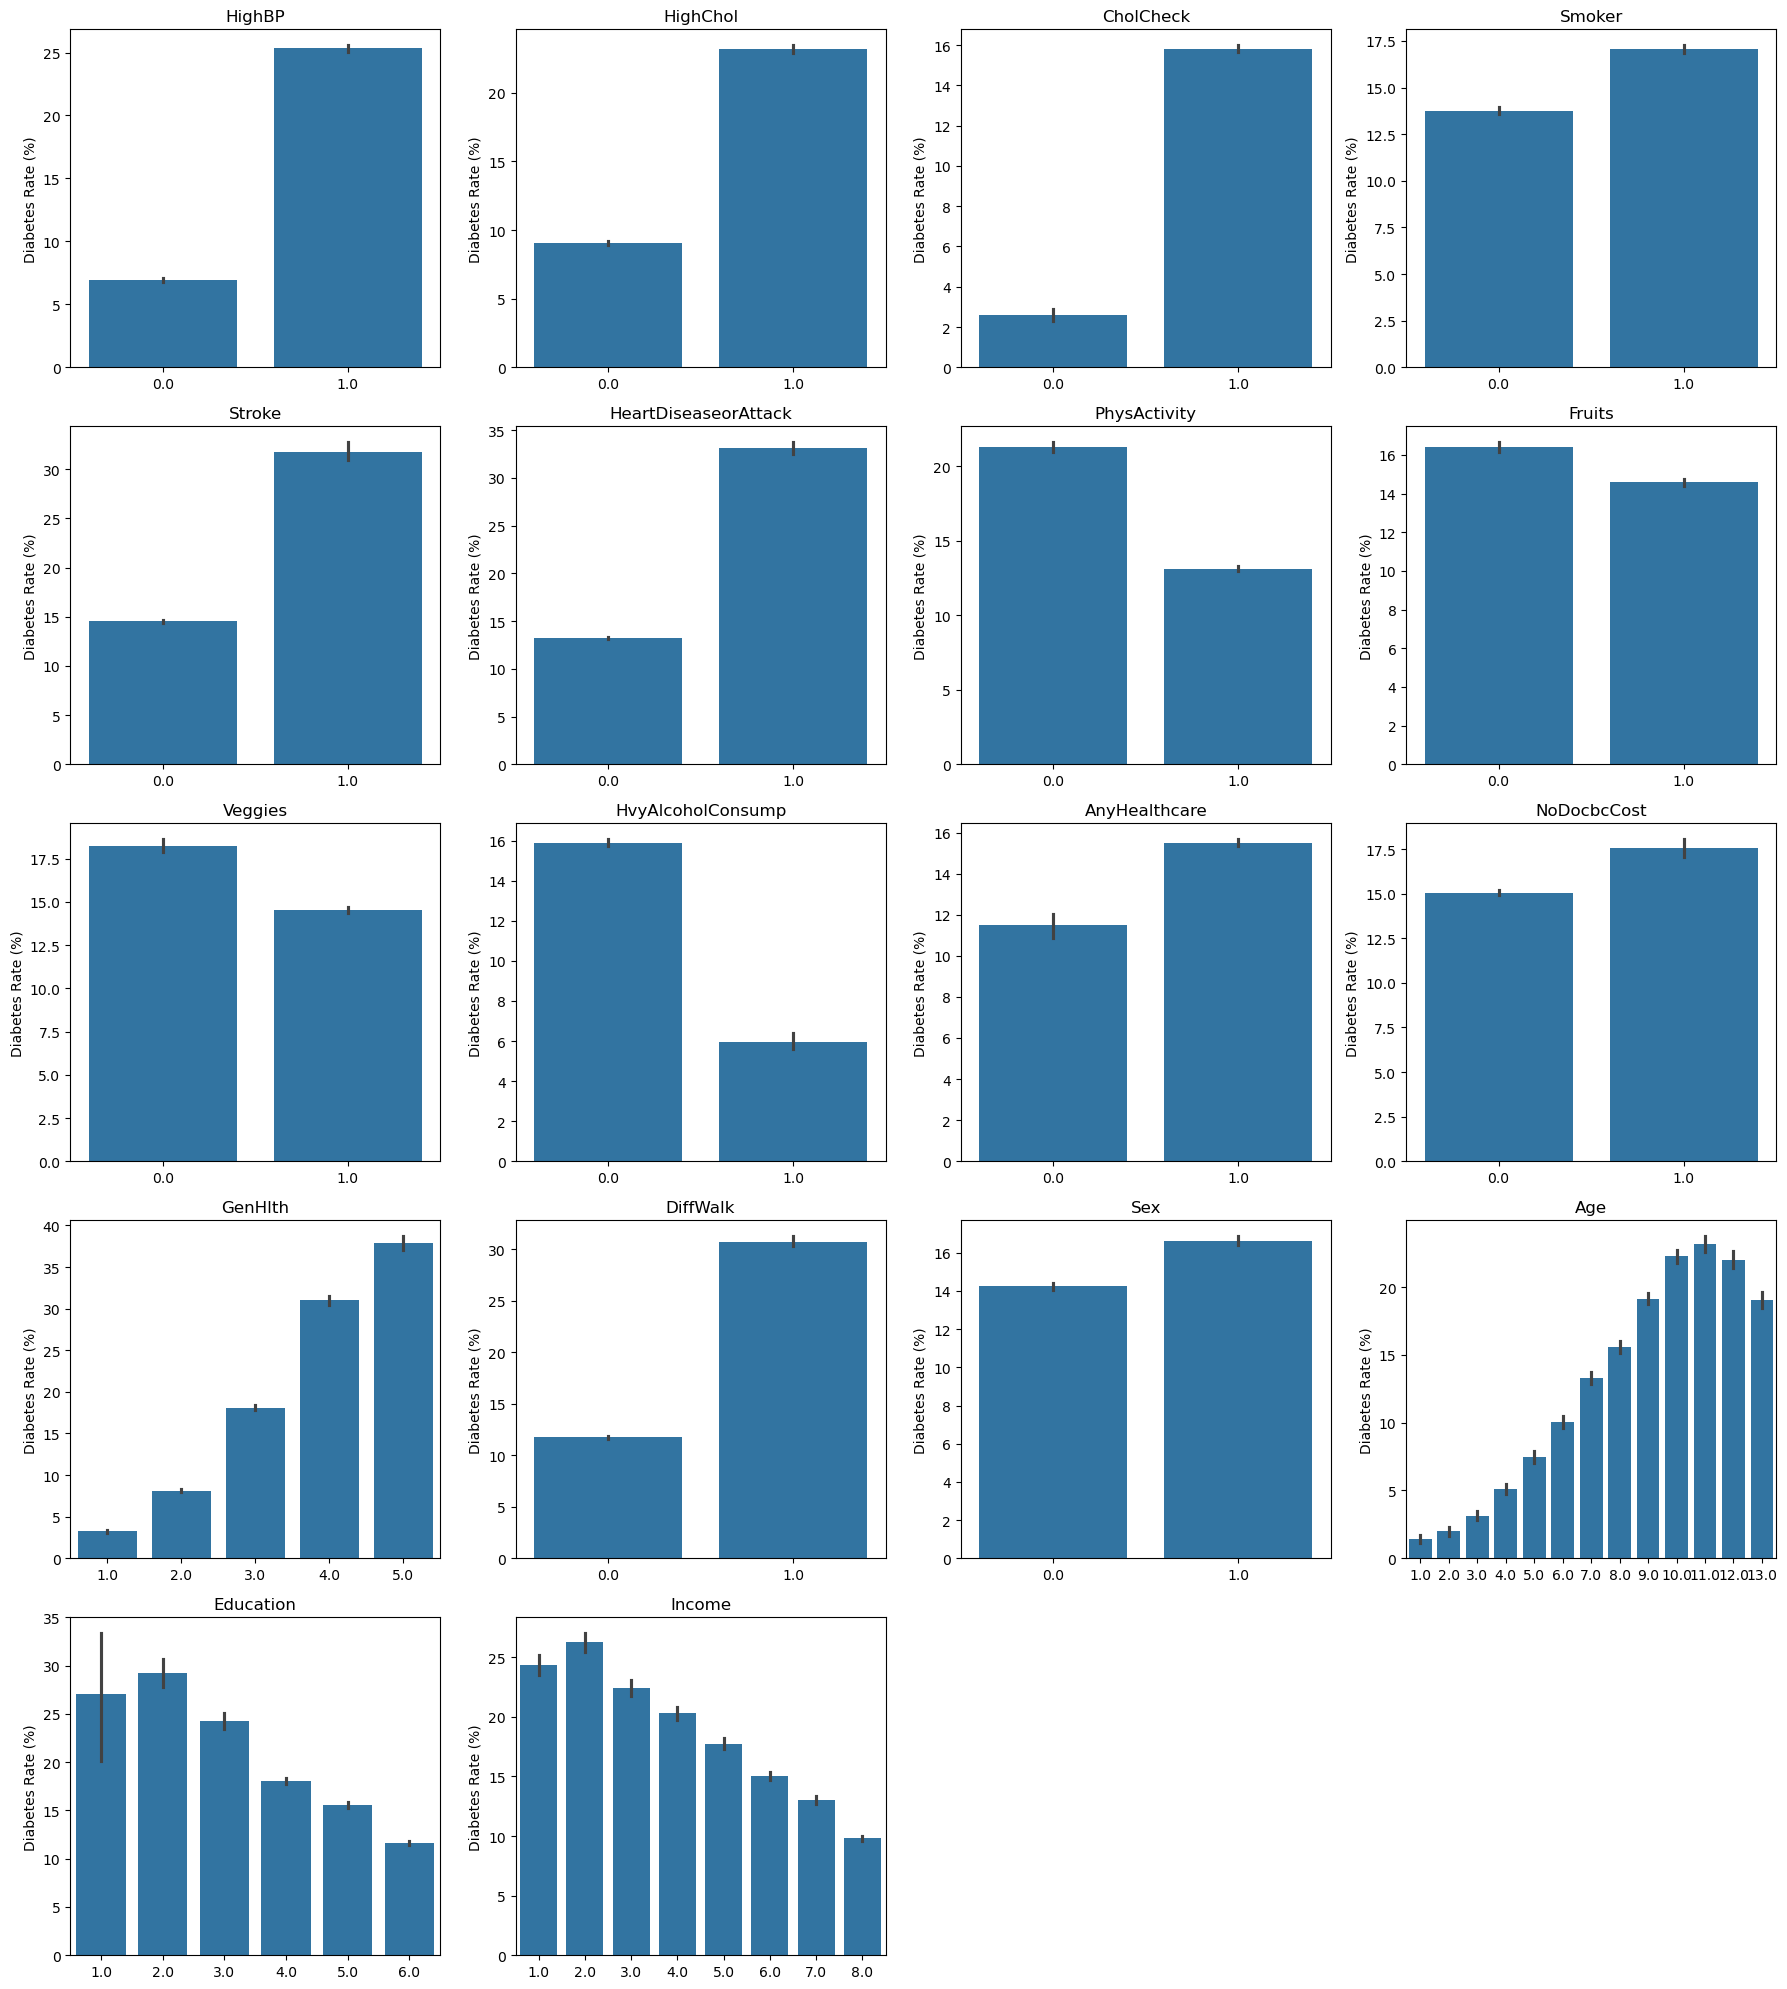

In [42]:
# =============================================================================
# BINARY FEATURES VS TARGET (COMBINED VISUALIZATION)
# =============================================================================


print("=" * 70)
print("BINARY FEATURES VS DIABETES STATUS")
print("=" * 70)


binary_features = categorical_features


n_features = len(binary_features)

cols = 4
rows = (n_features + cols - 1) // cols


fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(18, rows*4)
)


axes = axes.flatten()


for i, feature in enumerate(binary_features):
    
    sns.barplot(
        data=df,
        x=feature,
        y=target_column,
        ax=axes[i],
        estimator=lambda x: x.mean()*100
    )
    
    axes[i].set_title(
        f"{feature}"
    )
    
    axes[i].set_ylabel(
        "Diabetes Rate (%)"
    )
    
    axes[i].set_xlabel(
        ""
    )


# Remove unused plots
for j in range(i+1, len(axes)):
    axes[j].remove()


plt.tight_layout()
plt.show()

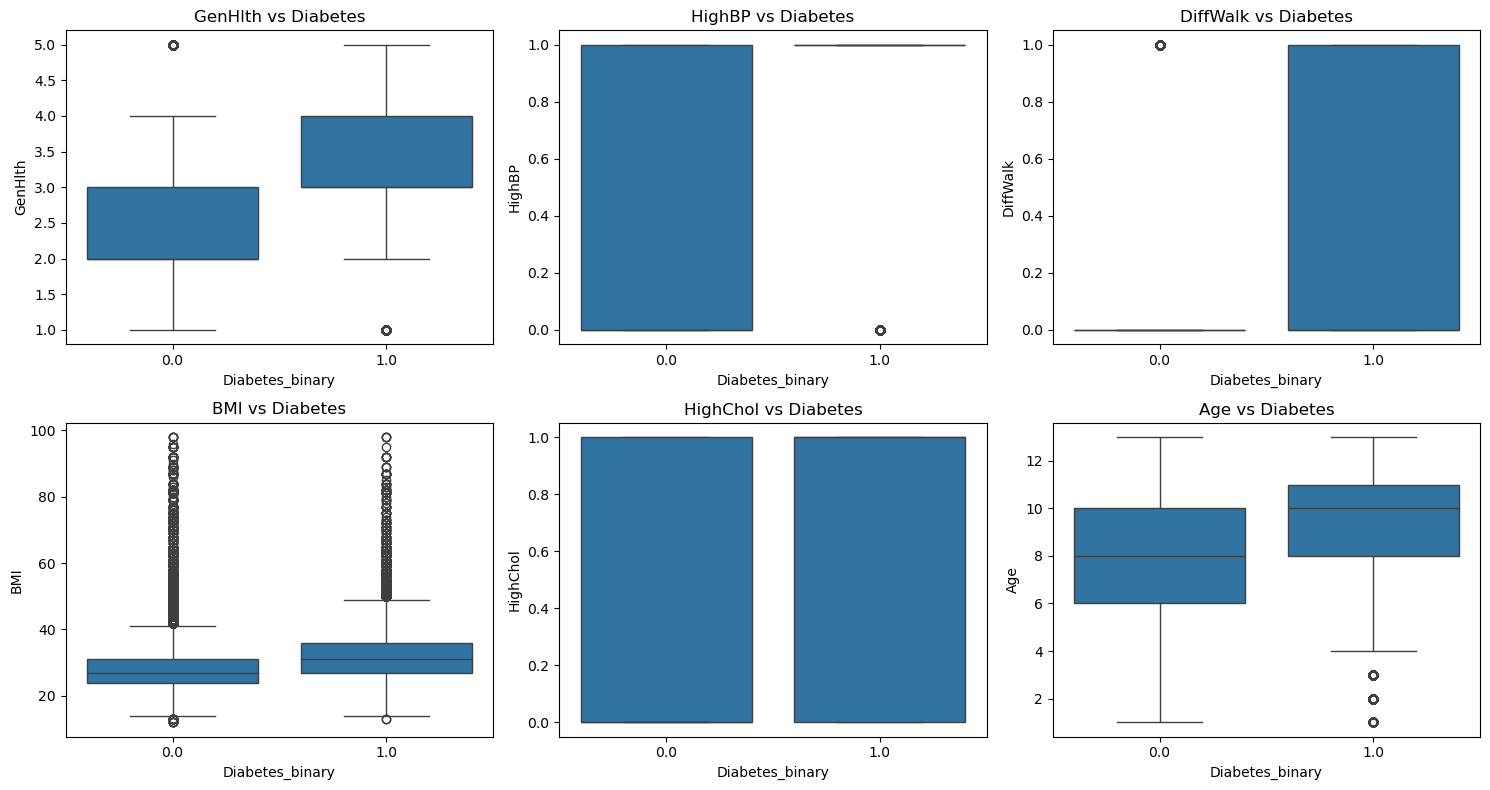

In [44]:
# =============================================================================
# TOP FEATURES VS TARGET (COMBINED)
# =============================================================================


top_features = [
    "GenHlth",
    "HighBP",
    "DiffWalk",
    "BMI",
    "HighChol",
    "Age"
]


fig, axes = plt.subplots(
    2,
    3,
    figsize=(15,8)
)


axes = axes.flatten()


for i, feature in enumerate(top_features):
    
    sns.boxplot(
        data=df,
        x=target_column,
        y=feature,
        ax=axes[i]
    )
    
    axes[i].set_title(
        f"{feature} vs Diabetes"
    )


plt.tight_layout()
plt.show()

In [45]:
# =============================================================================
# STEP 9: EDA SUMMARY
# =============================================================================


print("=" * 70)
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print("=" * 70)


eda_summary = pd.DataFrame({
    "EDA Component": [
        "Dataset Size",
        "Features",
        "Missing Values",
        "Duplicate Records",
        "Target Variable",
        "Class Distribution",
        "Highest Positive Correlation",
        "Highest Negative Correlation",
        "Major Outlier Features"
    ],
    
    "Findings": [
        f"{df.shape[0]} rows and {df.shape[1]} columns",
        
        ", ".join(df.columns),
        
        f"{df.isnull().sum().sum()} missing values detected",
        
        f"{duplicate_count} duplicate rows removed",
        
        target_column,
        
        (
            f"Class 0: {round((df[target_column].value_counts(normalize=True)[0])*100,2)}%, "
            f"Class 1: {round((df[target_column].value_counts(normalize=True)[1])*100,2)}%"
        ),
        
        (
            "GenHlth (0.277), HighBP (0.254), "
            "DiffWalk (0.205), BMI (0.205)"
        ),
        
        (
            "Income (-0.141), Education (-0.103), "
            "PhysActivity (-0.100)"
        ),
        
        (
            "MentHlth (15.76%), "
            "PhysHlth (14.97%), "
            "BMI (2.46%)"
        )
    ]
})


display(eda_summary)

EXPLORATORY DATA ANALYSIS SUMMARY


,EDA Component,Findings
0,Dataset Size,229474 rows and 22 columns
1,Features,"Diabetes_binary, HighBP, HighChol, CholCheck, ..."
2,Missing Values,0 missing values detected
3,Duplicate Records,24206 duplicate rows removed
4,Target Variable,Diabetes_binary
5,Class Distribution,"Class 0: 84.71%, Class 1: 15.29%"
6,Highest Positive Correlation,"GenHlth (0.277), HighBP (0.254), DiffWalk (0.2..."
7,Highest Negative Correlation,"Income (-0.141), Education (-0.103), PhysActiv..."
8,Major Outlier Features,"MentHlth (15.76%), PhysHlth (14.97%), BMI (2.46%)"


In [47]:
# =============================================================================
# STEP 10: SAVE CLEANED DATASET
# =============================================================================


import os

# Create processed data folder
os.makedirs("processed_data", exist_ok=True)


# Save cleaned dataset
df_clean.to_csv(
    "../../../data/processed/diabetes_cleaned.csv",
    index=False
)


print("Cleaned dataset saved successfully")

print("\nSaved File:")
print("processed_data/diabetes_cleaned.csv")

print("\nDataset Shape:")
print(df_clean.shape)

Cleaned dataset saved successfully

Saved File:
processed_data/diabetes_cleaned.csv

Dataset Shape:
(229474, 22)
